<a href="https://colab.research.google.com/github/prakhya-27/internship-week-1/blob/main/week2_mflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [2]:
import pandas as pd

df = pd.read_csv('w2data.csv')

print("Original Data:")
print(df.head())


Original Data:
  Observation  Y-Kappa  ChipRate  BF-CMratio  BlowFlow  ChipLevel4   \
0    31-00:00    23.10    16.520     121.717  1177.607      169.805   
1    31-01:00    27.60    16.810      79.022  1328.360      341.327   
2    31-02:00    23.19    16.709      79.562  1329.407      239.161   
3    31-03:00    23.60    16.478      81.011  1334.877      213.527   
4    31-04:00    22.90    15.618      93.244  1334.168      243.131   

   T-upperExt-2   T-lowerExt-2    UCZAA  WhiteFlow-4   ...  SteamFlow-4   \
0        358.282         329.545  1.443       599.253  ...        67.122   
1        351.050         329.067  1.549       537.201  ...        60.012   
2        350.022         329.260  1.600       549.611  ...        61.304   
3        350.938         331.142  1.604       623.362  ...        68.496   
4        351.640         332.709    NaN       638.672  ...        70.022   

   Lower-HeatT-3  Upper-HeatT-3   ChipMass-4   WeakLiquorF   BlackFlow-2   \
0        329.432        

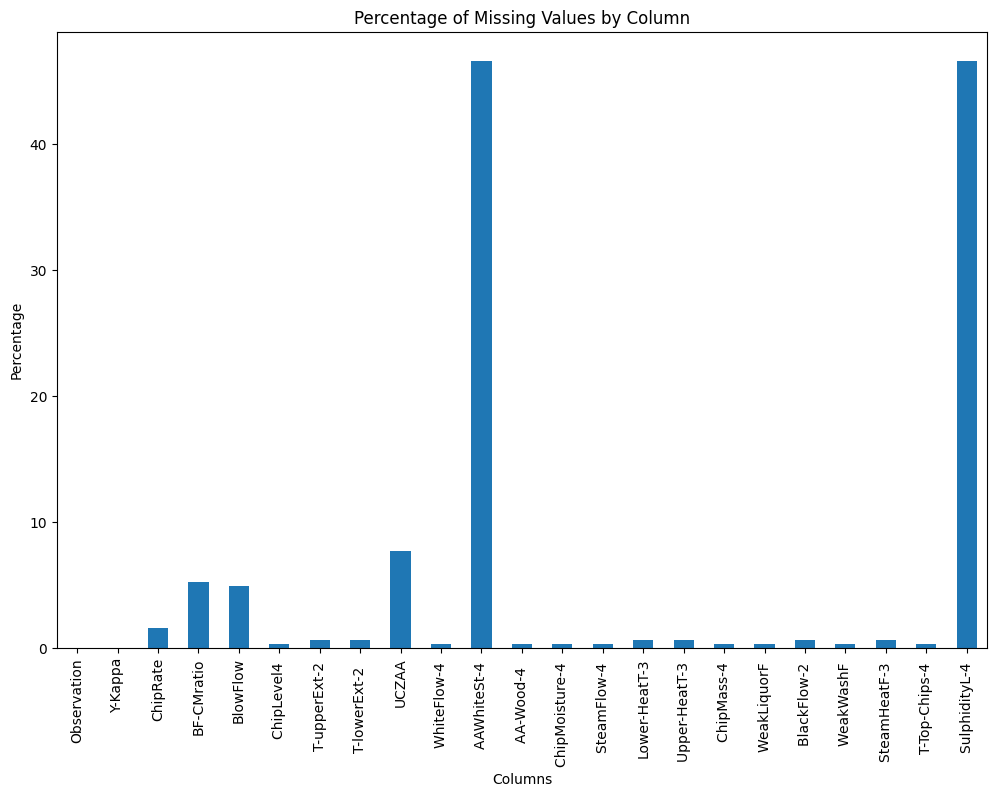

In [3]:
missing_values = df.isnull().mean() * 100
plt.figure(figsize=(12, 8))
missing_values.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.xlabel('Columns')
plt.show()

In [5]:
# Rename columns for easier access (optional)
df.columns = df.columns.str.replace(' ', '_')

# Handle missing values
df_cleaned = df.dropna()

print("\nData Types Before Cleaning:")
print(df.dtypes)


Data Types Before Cleaning:
Observation         object
Y-Kappa            float64
ChipRate           float64
BF-CMratio         float64
BlowFlow           float64
ChipLevel4_        float64
T-upperExt-2_      float64
T-lowerExt-2__     float64
UCZAA              float64
WhiteFlow-4_       float64
AAWhiteSt-4_       float64
AA-Wood-4__        float64
ChipMoisture-4_    float64
SteamFlow-4_       float64
Lower-HeatT-3      float64
Upper-HeatT-3_     float64
ChipMass-4_        float64
WeakLiquorF_       float64
BlackFlow-2_       float64
WeakWashF_         float64
SteamHeatF-3_      float64
T-Top-Chips-4_     float64
SulphidityL-4_     float64
dtype: object


In [6]:
print("\nNumber of Duplicate Rows Before Cleaning:", df.duplicated().sum())

# Handle duplicate rows if any
df_cleaned = df_cleaned.drop_duplicates()

#Scale or normalize the data if necessary
scaler = StandardScaler()


Number of Duplicate Rows Before Cleaning: 23


In [7]:

# Identifying numerical columns
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

df_cleaned[numerical_columns] = scaler.fit_transform(df_cleaned[numerical_columns])


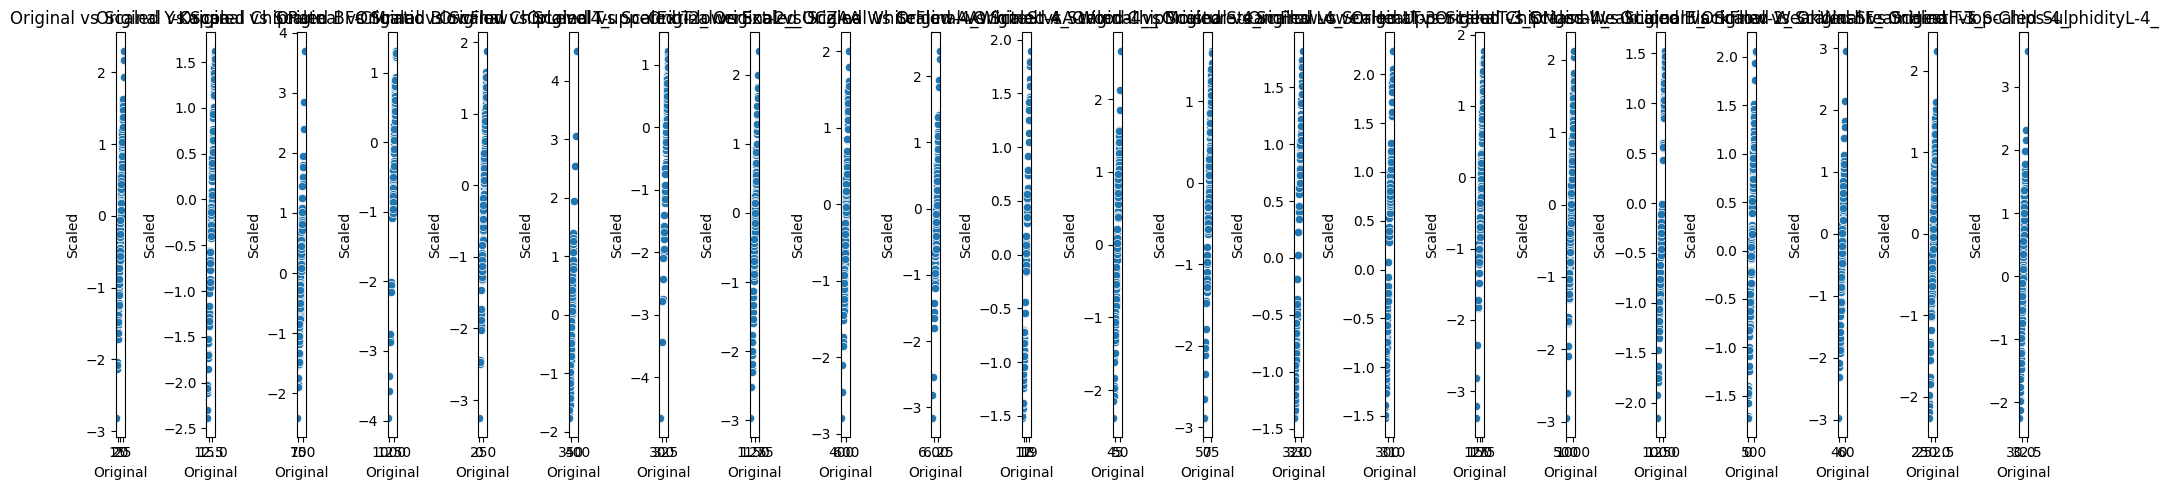

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming numerical_columns, df, and df_cleaned are already defined
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_columns), figsize=(20, 5))

for i, col in enumerate(numerical_columns):
    sns.scatterplot(x=df[col], y=df_cleaned[col], ax=axes[i])
    axes[i].set_xlabel('Original')
    axes[i].set_ylabel('Scaled')
    axes[i].set_title(f'Original vs Scaled {col}')

plt.tight_layout()
plt.show()


In [ ]:
print("Cleaned and Preprocessed Data:")
print(df_cleaned.head())


Cleaned and Preprocessed Data:
  Observation   Y-Kappa  ChipRate  BF-CMratio  BlowFlow  ChipLevel4_  \
1    31-01:00  2.303414  1.620088   -1.035649  1.222801     0.930053   
3    31-03:00  0.974702  1.397338   -0.770606  1.313191    -0.637383   
5     1-08:00 -2.137807  0.640523   -0.170028 -0.951384    -0.821219   
7    31-06:00  0.659133 -0.198146    0.678668  0.938358     0.288140   
9    31-08:00  1.340098 -0.365880    1.254460  1.313399     1.189870   

   T-upperExt-2_  T-lowerExt-2__     UCZAA  WhiteFlow-4_  ...  SteamFlow-4_  \
1      -0.617456        0.631089  0.484237     -0.851819  ...     -1.296924   
3      -0.629411        0.896509  1.002651      0.416239  ...      0.238047   
5      -1.368538        0.135810 -0.580868      0.488104  ...     -0.353760   
7      -0.481778        0.899067 -0.279246      0.448426  ...      0.745000   
9      -0.476334        0.412486  0.163763     -0.616769  ...     -0.530343   

   Lower-HeatT-3  Upper-HeatT-3_  ChipMass-4_  WeakLiquorF_  